## The problem ordinary regression ignores

Suppose you want to test whether brain size scales with body size across mammals, or whether flower color predicts pollinator visitation across plant species. The natural instinct is to collect one data point per species and run an ordinary least squares (OLS) regression. This is wrong, and has been known to be wrong since Felsenstein's foundational 1985 paper.

The reason is simple. Species are not independent samples from some population; they are the tips of a phylogenetic tree. Two closely related species — say, a chimpanzee and a bonobo — resemble each other not because of some causal relationship between the traits under study, but because they inherited both traits from a recent common ancestor. Standard regression assumes residuals are independently and identically distributed. When your data points are structured by a phylogeny, that assumption is violated, and violated systematically: closely related species will tend to have correlated residuals. The practical consequence is that OLS understates its own uncertainty. Effective sample size is smaller than the number of species you counted, degrees of freedom are inflated, and p-values are optimistic — sometimes dramatically so (Felsenstein 1985; Freckleton et al. 2002).

Phylogenetic Generalized Least Squares (PGLS) addresses this directly. Rather than discarding the phylogeny or trying to "correct for" it after the fact, PGLS builds the expected pattern of non-independence into the regression itself, as a covariance structure on the residuals.

## From independent contrasts to PGLS

Felsenstein's original solution was phylogenetically independent contrasts (PICs): transform the raw trait values into a set of statistically independent contrasts computed along the branches of the tree, then run a standard regression on the contrasts, forced through the origin (Felsenstein 1985). This works well but is somewhat inflexible — it handles only Brownian motion evolution, offers no natural way to include multiple predictors or categorical covariates, and doesn't extend cleanly to generalized linear models.

Grafen (1989) reframed the problem as one of generalized least squares regression, showing that PICs are mathematically equivalent to a GLS fit in which the residual covariance matrix is derived from the tree. Martins and Hansen (1997) generalized this further, and Pagel (1997, 1999) introduced scaling parameters — most importantly λ (lambda) — that let the strength of the phylogenetic signal in the residuals be estimated from the data rather than assumed. Freckleton, Harvey, and Pagel (2002) demonstrated that this λ-based approach is robust and statistically powerful even when the phylogeny is incompletely known. This is the method now generally called PGLS, and it is the standard tool in modern phylogenetic comparative biology (Symonds and Blomberg 2014).

## The model, formally

An ordinary least squares regression assumes

$$y = X\beta + \varepsilon, \quad \varepsilon \sim N(0, \sigma^2 I)$$

that is, residuals are independent and identically distributed with covariance matrix $\sigma^2 I$. PGLS replaces this with

$$y = X\beta + \varepsilon, \quad \varepsilon \sim N(0, \sigma^2 V)$$

where $V$ is an $n \times n$ matrix encoding the expected covariance between species' residuals, derived from the phylogeny. Under a Brownian motion model of evolution, the covariance between two species is proportional to the amount of shared branch length between them and the root: closely related species (which share a longer path from the root) get a higher covariance, tips connected only near the root get a lower one. The generalized least squares estimator is then

$$\hat{\beta} = (X^\top V^{-1} X)^{-1} X^\top V^{-1} y$$

which is just OLS after "whitening" the data by the inverse of the phylogenetic covariance structure. In practice, $V$ is rarely used raw; it is common to allow it to be scaled by Pagel's $\lambda$, which multiplies the off-diagonal (shared ancestry) elements of the correlation matrix by $\lambda$ while leaving the diagonal untouched. $\lambda = 1$ recovers the full Brownian expectation; $\lambda = 0$ collapses the model back to OLS, since it implies no phylogenetic signal in the residuals at all. $\lambda$ is estimated by maximum likelihood alongside the regression coefficients, so the data themselves tell you how much phylogenetic correction is warranted (Pagel 1999; Freckleton et al. 2002).

## Worked example in R

The example below is fully self-contained: it simulates a tree and trait data with a known phylogenetic structure, so PGLS can be shown recovering the correct relationship where OLS does not.

### Packages

`ape` provides the phylogenetic infrastructure — tree objects, trait simulation, and the correlation structures (`corBrownian`, `corPagel`, `corMartins`, `corGrafen`) that plug directly into `nlme::gls()`. This combination is the base implementation of PGLS in R (Paradis and Schliep 2019; Pinheiro and Bates 2000). The `caper` package (Orme et al. 2013) offers a popular alternative interface (`caper::pgls`) built specifically for comparative datasets, and `phytools` (Revell 2012) provides complementary tools for tree manipulation and visualization; either integrates well with the workflow below.

In [1]:
install.packages(c("ape", "nlme"))   # if not already installed
library(ape)   # tree handling and correlation structures
library(nlme)  # gls(), the workhorse for PGLS


The downloaded binary packages are in
	/var/folders/vm/xtvv8jb542s04t61c12lsnvr0000gn/T//RtmpgOJBH7/downloaded_packages


### Simulating a tree and correlated trait data

In [2]:
set.seed(123)

# 1. A random ultrametric tree with 40 tips ("species")
tree <- rcoal(40)
tree$tip.label <- paste0("sp", 1:40)

# 2. A predictor trait evolving under Brownian motion along the tree
x <- rTraitCont(tree, model = "BM", sigma = 1)

# 3. A response trait built as a linear function of x (true slope = 0.8),
#    plus its own phylogenetically structured error term
phylo_error <- rTraitCont(tree, model = "BM", sigma = 0.5)
y <- 0.8 * x + phylo_error

dat <- data.frame(species = tree$tip.label, x = x, y = y)
rownames(dat) <- dat$species
head(dat)

,species,x,y
,<chr>,<dbl>,<dbl>
sp1,sp1,1.533555,1.119959
sp2,sp2,1.578064,1.176384
sp3,sp3,1.524573,1.050779
sp4,sp4,1.752620,1.301077
sp5,sp5,1.429647,2.070559
sp6,sp6,1.223539,1.970735


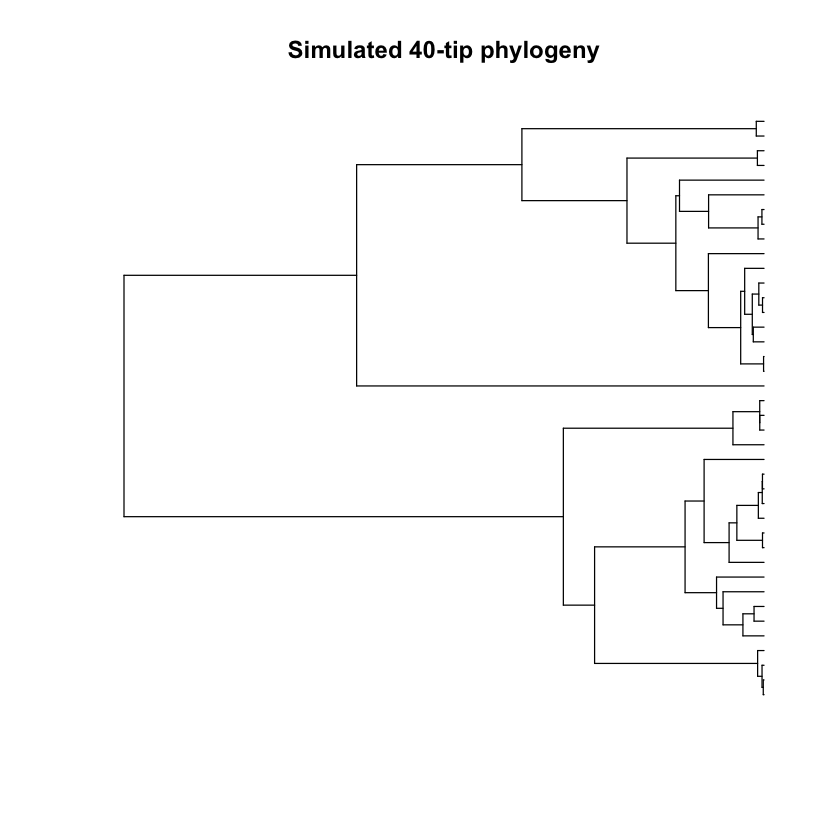

In [3]:
plot(tree, show.tip.label = FALSE, main = "Simulated 40-tip phylogeny")

Because both `x` and the error term were generated under Brownian motion on the same tree, the residuals of any regression of `y` on `x` will themselves carry phylogenetic signal — exactly the situation PGLS is designed for.

### Naive OLS (ignoring the phylogeny)

In [4]:
m_ols <- lm(y ~ x, data = dat)
summary(m_ols)$coefficients

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),-0.1581428,0.09203221,-1.718342,9.387331e-02
x,1.1539112,0.08223846,14.031284,1.304257e-16


OLS estimates the slope well above the true value of 0.8, with a tight standard error and an extremely small p-value. This is precisely the failure mode Felsenstein warned about: shared ancestry inflates the apparent strength and certainty of the relationship.

### PGLS assuming Brownian motion

In [5]:
corBM <- corBrownian(1, phy = tree, form = ~species)
m_bm <- gls(y ~ x, data = dat, correlation = corBM, method = "ML")
summary(m_bm)$tTable

,Value,Std.Error,t-value,p-value
(Intercept),-0.3596555,0.4085034,-0.8804222,3.841651e-01
x,0.8462925,0.0751379,11.2631903,1.131397e-13


Once the Brownian covariance structure is built into the residuals, the slope estimate sits much closer to the true value (0.8), and the standard error is appropriately larger, reflecting the smaller effective sample size once phylogenetic redundancy is accounted for.

### PGLS with Pagel's λ estimated from the data

In [6]:
corPagel_str <- corPagel(value = 0.5, phy = tree, form = ~species)
m_lambda <- gls(y ~ x, data = dat, correlation = corPagel_str, method = "ML")
summary(m_lambda)$tTable

,Value,Std.Error,t-value,p-value
(Intercept),-0.3579659,0.41925874,-0.8538067,3.985625e-01
x,0.8421314,0.07516831,11.2032762,1.323633e-13


In [7]:
m_lambda$modelStruct$corStruct

Correlation structure of class corPagel representing
  lambda 
1.000392 

Here λ is estimated at essentially 1, correctly recovering the fact that the simulated residual error really was generated under pure Brownian motion. In real data, λ will rarely be exactly 0 or 1; it is precisely this intermediate value that tells you how much phylogenetic correction the data support, rather than forcing an all-or-nothing assumption.

### Comparing models

In [8]:
AIC(m_ols, m_bm, m_lambda)

,df,AIC
,<dbl>,<dbl>
m_ols,3,49.61137
m_bm,3,-35.29059
m_lambda,4,-33.89102


Both PGLS models vastly outperform OLS by AIC, confirming that the phylogenetic structure in the residuals is real and that ignoring it costs a great deal of model fit. The Brownian and λ models are nearly indistinguishable here (as expected, since λ ≈ 1), but in general, letting λ be estimated rather than fixed at 1 is the safer default, since it nests both extremes.

## Applying this to your own data

1. **Match your tips to your data.** The tree's tip labels and your data frame's row names (or a species-name column) must correspond exactly; mismatches are the most common source of silent errors.
2. **Prune the tree to your species.** Use `ape::keep.tip()` (or `drop.tip()`) to reduce a large reference phylogeny down to just the species in your dataset before fitting.
3. **Check for polytomies and zero-length branches.** These can make some correlation structures numerically unstable; `ape::multi2di()` resolves polytomies at random for testing purposes, though ideally branch lengths should come from a proper phylogenetic analysis.
4. **Don't assume Brownian motion by default.** Fit λ (or, alternatively, Pagel's κ or δ, or an Ornstein-Uhlenbeck model via `ape::corMartins`) and let the likelihood tell you which structure the data support, rather than hard-coding an assumption.
5. **Diagnose the fitted model** as you would any GLS: examine standardized residuals for outliers or remaining structure, and consider whether the trait itself might need a transformation before modeling.

## Common pitfalls

- Fitting PGLS with `method = "REML"` when comparing models with different fixed effects via likelihood ratio tests or AIC; use `method = "ML"` for that purpose, and switch to REML only when your final model's fixed effects are settled.
- Treating a λ estimate of 0 as evidence that phylogeny "doesn't matter" without checking the confidence interval on λ; with modest sample sizes, that interval is often wide.
- Applying PGLS to trait pairs measured on different subsets of species without pruning both the tree and the data consistently.
- Forgetting that PGLS corrects for correlated residuals due to shared ancestry — it does not, by itself, tell you whether a relationship is causal or convergent.

## References

Felsenstein, J. (1985). Phylogenies and the comparative method. *The American Naturalist*, 125(1), 1–15.

Freckleton, R. P., Harvey, P. H., & Pagel, M. (2002). Phylogenetic analysis and comparative data: A test and review of evidence. *The American Naturalist*, 160(6), 712–726.

Grafen, A. (1989). The phylogenetic regression. *Philosophical Transactions of the Royal Society of London B*, 326(1233), 119–157.

Martins, E. P., & Hansen, T. F. (1997). Phylogenies and the comparative method: A general approach to incorporating phylogenetic information into the analysis of interspecific data. *The American Naturalist*, 149(4), 646–667.

Orme, D., Freckleton, R., Thomas, G., Petzoldt, T., Fritz, S., Isaac, N., & Pearse, W. (2013). *caper: Comparative Analyses of Phylogenetics and Evolution in R.* R package.

Pagel, M. (1999). Inferring the historical patterns of biological evolution. *Nature*, 401(6756), 877–884.

Paradis, E., & Schliep, K. (2019). ape 5.0: An environment for modern phylogenetics and evolutionary analyses in R. *Bioinformatics*, 35(3), 526–528.

Pinheiro, J., & Bates, D. (2000). *Mixed-Effects Models in S and S-PLUS.* Springer.

Revell, L. J. (2012). phytools: An R package for phylogenetic comparative biology (and other things). *Methods in Ecology and Evolution*, 3(2), 217–223.

Symonds, M. R. E., & Blomberg, S. P. (2014). A primer on phylogenetic generalised least squares. In L. Z. Garamszegi (Ed.), *Modern Phylogenetic Comparative Methods and Their Application in Evolutionary Biology* (pp. 105–130). Springer.